# Import

In [1]:
from DNN import DNN
from Utils import *
import os
from torch.utils.data import DataLoader

PATH_PROJECT_ROBIN = "/home/robin/Bureau/ETUDES/M2/S2/TAP/"
PATH_PROJECT_QUENTIN = "..."
PATH_PROJECT_PERSONNE = PATH_PROJECT_ROBIN
PATH_RAW_DATASET = "Projet-Traitement-Automatique-de-la-Parole/Dataset/"
GLOBAL_PATH_DATASET = os.path.join(PATH_PROJECT_PERSONNE, PATH_RAW_DATASET)
GLOBAL_PATH_RAW_DATASET = os.path.join(GLOBAL_PATH_DATASET, "speech_commands_v0.02/")
GLOBAL_PATH_BASIC_DATASET = os.path.join(GLOBAL_PATH_DATASET, "Dataset_basique/")
filename = os.path.join(GLOBAL_PATH_DATASET, "dataset_basique.pkl")

# Get dataset

In [2]:
with open(filename, "rb") as f:
    data = pickle.load(f)

In [3]:
x_train, y_train, metadata_train = data["train"]["signals"], data["train"]["labels"], data["train"]["metadata"]
x_val, y_val, metadata_val = data["val"]["signals"], data["val"]["labels"], data["val"]["metadata"]
x_test, y_test, metadata_test = data["test"]["signals"], data["test"]["labels"], data["test"]["metadata"]

train_dataset = SpeechCommandDataset(x_train, y_train, metadata_train, transform_type="MFCC")
val_dataset = SpeechCommandDataset(x_val, y_val, metadata_val, transform_type="MFCC")
test_dataset = SpeechCommandDataset(x_test, y_test, metadata_test, transform_type="MFCC")

train_loader = DataLoader(train_dataset, batch_size=100, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=100, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=100, shuffle=True)

# Create model

In [4]:
model = DNN((1, 40, 97),6).apply(init_weights_normal)

# Train model

In [5]:
model, train_loss, val_acc, val_loss = train(model,train_loader,val_loader,nb_steps=10000)

plot_all_data([([(val_acc,"DNN","red")],"Accuracy Trend over Validation Set","Training step","Validation set accuracy",400,20,100),
               ([(val_loss,"DNN","red")],"Loss Trend over Validation Set","Training step","Validation set Loss",400,0,5),
               ([(train_loss,"DNN","red")],"Loss Trend over Train Set","Training step","Train set Loss",1,0,5)])

Début de l'entraînement sur cpu...
Step 400/10000 | Loss: 1.7809 | Val Acc: 16.79% | Temps: 1.20s
Step 800/10000 | Loss: 1.7380 | Val Acc: 19.01% | Temps: 3.52s
Step 1200/10000 | Loss: 1.6722 | Val Acc: 32.17% | Temps: 6.61s
Step 1600/10000 | Loss: 1.4875 | Val Acc: 33.78% | Temps: 10.18s
Step 2000/10000 | Loss: 1.5491 | Val Acc: 34.39% | Temps: 14.17s
Step 2400/10000 | Loss: 1.5524 | Val Acc: 34.32% | Temps: 16.85s
Step 2800/10000 | Loss: 1.4032 | Val Acc: 34.72% | Temps: 20.40s
Step 3200/10000 | Loss: 1.3596 | Val Acc: 34.72% | Temps: 23.94s
Step 3600/10000 | Loss: 1.4078 | Val Acc: 34.79% | Temps: 26.41s
Step 4000/10000 | Loss: 1.3627 | Val Acc: 35.66% | Temps: 28.60s
Step 4400/10000 | Loss: 1.2830 | Val Acc: 37.74% | Temps: 30.68s
Step 4800/10000 | Loss: 1.5082 | Val Acc: 37.27% | Temps: 32.84s
Step 5200/10000 | Loss: 1.2932 | Val Acc: 41.77% | Temps: 35.13s
Step 5600/10000 | Loss: 1.3743 | Val Acc: 42.98% | Temps: 37.43s
Step 6000/10000 | Loss: 1.2519 | Val Acc: 45.00% | Temps: 41

KeyboardInterrupt: 

# Test and plot model

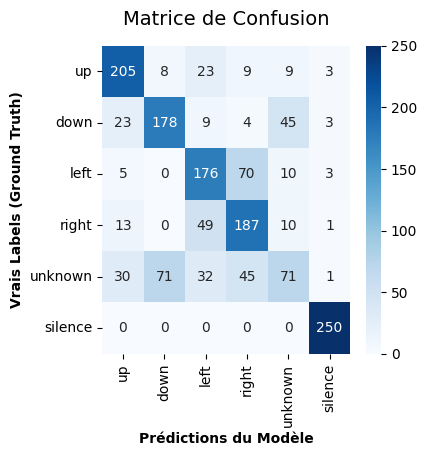

In [ ]:
accuracy, all_preds, all_labels, all_probs, loss = evaluate(model, test_loader)
cm = plot_custom_confusion_matrix(all_preds, all_labels, class_names=data['mapping'])

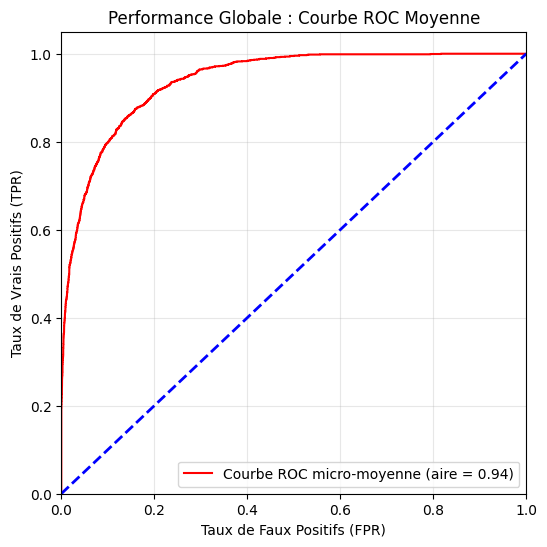

In [ ]:
plot_roc_curve(all_labels, all_probs, 6)

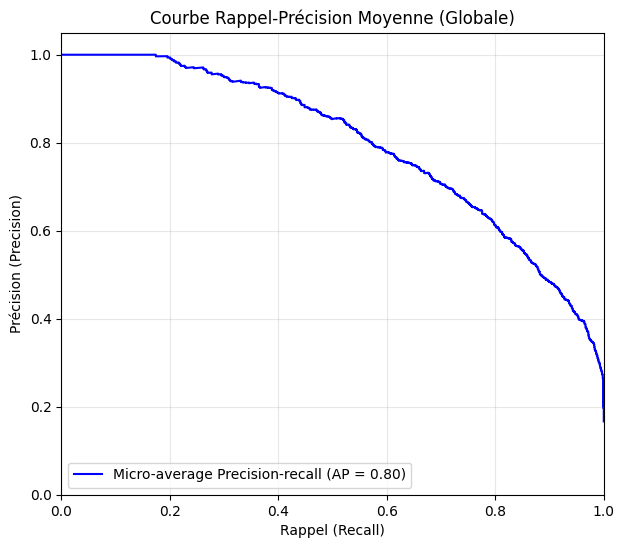

In [ ]:
plot_precision_recall_curve(all_labels, all_probs, 6)